# Generación de Conjuntos de Datos de Regresión
## (Hechos a la medida)

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## Funciones

In [22]:
def generate_regression_dataset(
    n_samples=1000,
    n_features=1,
    complexity="linear",   # "linear" | "polynomial" | "sinusoidal" | "piecewise" | "interaction"
    noise_std=0.3,
    x_range=(-5, 5),
    random_state=None
):
    rng = np.random.default_rng(random_state)

    X = rng.uniform(x_range[0], x_range[1], size=(n_samples, n_features))
    X = np.round(X, 4)

    if complexity == "linear":
        if n_features == 1:
            y = 2.5 * X[:, 0] + 1.0
        else:
            coefs = np.arange(1, n_features + 1)
            y = X @ coefs + 1.0

    elif complexity == "polynomial":
        if n_features == 1:
            y = 0.5 * X[:, 0]**3 - 1.5 * X[:, 0]**2 + 2.0 * X[:, 0] + 3.0
        else:
            y = 0.8 * X[:, 0]**2 - 1.2 * X[:, 1] + 0.5 * X[:, 0] * X[:, 1]

    elif complexity == "sinusoidal":
        if n_features == 1:
            y = 3.0 * np.sin(X[:, 0]) + 0.3 * X[:, 0]
        else:
            y = 2.5 * np.sin(X[:, 0]) + 1.5 * np.cos(X[:, 1])

    elif complexity == "piecewise":
        if n_features == 1:
            y = np.where(
                X[:, 0] < 0,
                1.5 * X[:, 0] + 2,
                -2.0 * X[:, 0] + 2
            )
        else:
            y = np.where(
                X[:, 0] + X[:, 1] < 0,
                X[:, 0] - X[:, 1] + 2,
                -X[:, 0] + 1.5 * X[:, 1] - 1
            )

    elif complexity == "interaction":
        if n_features < 2:
            raise ValueError("interaction requiere al menos 2 variables.")
        y = 1.2 * X[:, 0] + 0.8 * X[:, 1] + 1.5 * X[:, 0] * X[:, 1]

    else:
        raise ValueError("Complejidad no reconocida.")

    noise = rng.normal(0, noise_std, size=n_samples)
    y = y + noise

    columns = [f"x{i+1}" for i in range(n_features)]
    df = pd.DataFrame(X, columns=columns)
    df["y"] = y

    return df

In [23]:
def plot_regression_dataset(df, target_col="y"):
    feature_cols = [col for col in df.columns if col != target_col]

    if len(feature_cols) == 1:
        x = df[feature_cols[0]]
        y = df[target_col]

        order = np.argsort(x.to_numpy())

        plt.figure(figsize=(8, 5))
        plt.scatter(x, y, alpha=0.6)
        plt.plot(x.to_numpy()[order], y.to_numpy()[order], alpha=0.7)
        plt.xlabel(feature_cols[0])
        plt.ylabel(target_col)
        plt.title("Dataset de Regresión (1D)")
        plt.grid(True)
        plt.show()

    elif len(feature_cols) == 2:
        x1 = df[feature_cols[0]]
        x2 = df[feature_cols[1]]
        y = df[target_col]

        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection="3d")
        scatter = ax.scatter(x1, x2, y, c=y, alpha=0.7)
        ax.set_xlabel(feature_cols[0])
        ax.set_ylabel(feature_cols[1])
        ax.set_zlabel(target_col)
        ax.set_title("Dataset de Regresión (2 Variables)")
        fig.colorbar(scatter, ax=ax, shrink=0.7)
        plt.show()

    else:
        raise ValueError("La función de graficación solo soporta 1 o 2 variables.")

In [24]:
def plot_regression_diagnostics(df, target_col="y", bins=30):
    feature_cols = [col for col in df.columns if col != target_col]

    if len(feature_cols) != 1:
        raise ValueError("Las visualizaciones diagnósticas están pensadas para datasets de 1 variable.")

    x = df[feature_cols[0]]
    y = df[target_col]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].scatter(x, y, alpha=0.6)
    axes[0].set_title("Dispersión")
    axes[0].set_xlabel(feature_cols[0])
    axes[0].set_ylabel(target_col)
    axes[0].grid(True)

    axes[1].hist(y, bins=bins, edgecolor="black")
    axes[1].set_title("Distribución de y")
    axes[1].set_xlabel(target_col)
    axes[1].set_ylabel("Frecuencia")
    axes[1].grid(True)

    axes[2].hist(x, bins=bins, edgecolor="black")
    axes[2].set_title("Distribución de x")
    axes[2].set_xlabel(feature_cols[0])
    axes[2].set_ylabel("Frecuencia")
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

In [25]:
def save_dataset(df, filename, base_path="../data/mocked_data"):
    output_dir = Path(base_path)
    output_dir.mkdir(parents=True, exist_ok=True)

    output_path = output_dir / filename
    df.to_csv(output_path, index=False)

    print(f"Dataset guardado en: {output_path}")

## Datos Generados

### Regresión Lineal Simple

In [26]:
df_1 = generate_regression_dataset(
    n_samples=3000,
    n_features=1,
    complexity="linear",
    noise_std=0.8,
    x_range=(-10, 10),
    random_state=42
)
df_1.head()

,x1,y
0,5.4791,15.542858
1,-1.2224,-2.660176
2,7.1720,16.738374
3,3.9474,9.454930
4,-8.1165,-18.153948


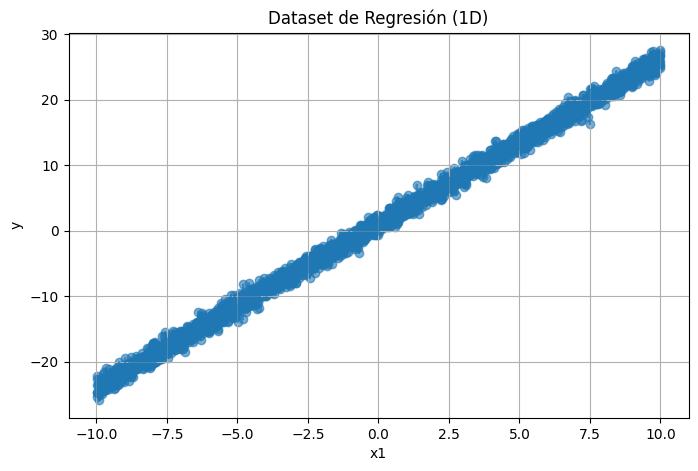

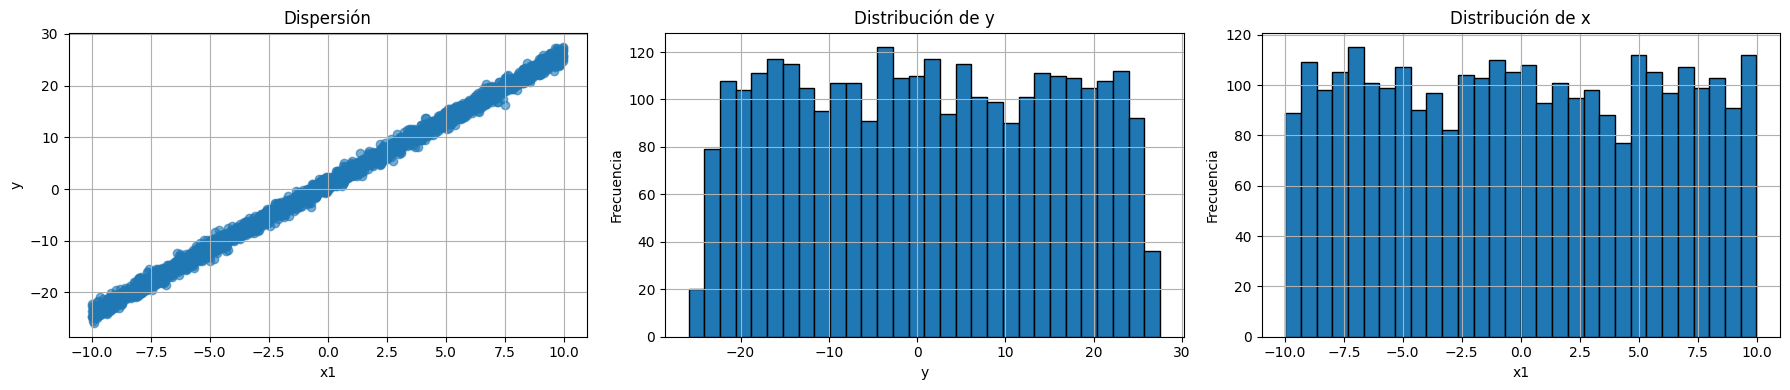

In [27]:
plot_regression_dataset(df_1, target_col="y")
plot_regression_diagnostics(df_1, target_col="y")

In [28]:
save_dataset(df_1, "regression_linear_1d.csv")

Dataset guardado en: ../data/mocked_data/regression_linear_1d.csv


### Regresión No Lineal Polinómica

In [29]:
df_2 = generate_regression_dataset(
    n_samples=3000,
    n_features=1,
    complexity="polynomial",
    noise_std=2.0,
    x_range=(-4, 5),
    random_state=42
)
df_2.head()

,x1,y
0,2.9656,10.892701
1,-0.0501,1.385533
2,3.7274,10.028804
3,2.2763,2.143735
4,-3.1524,-31.031670


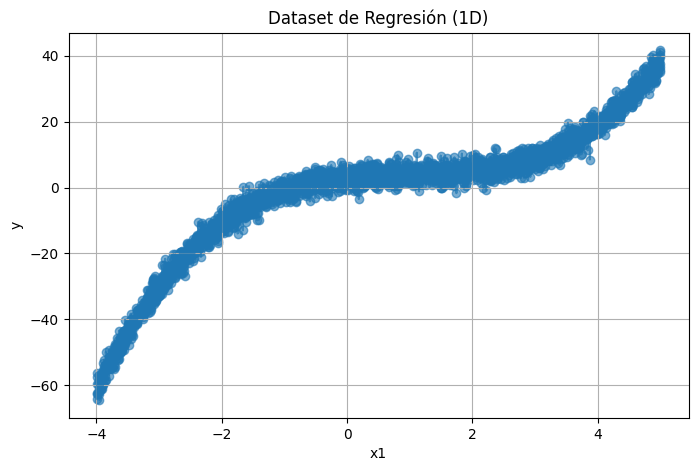

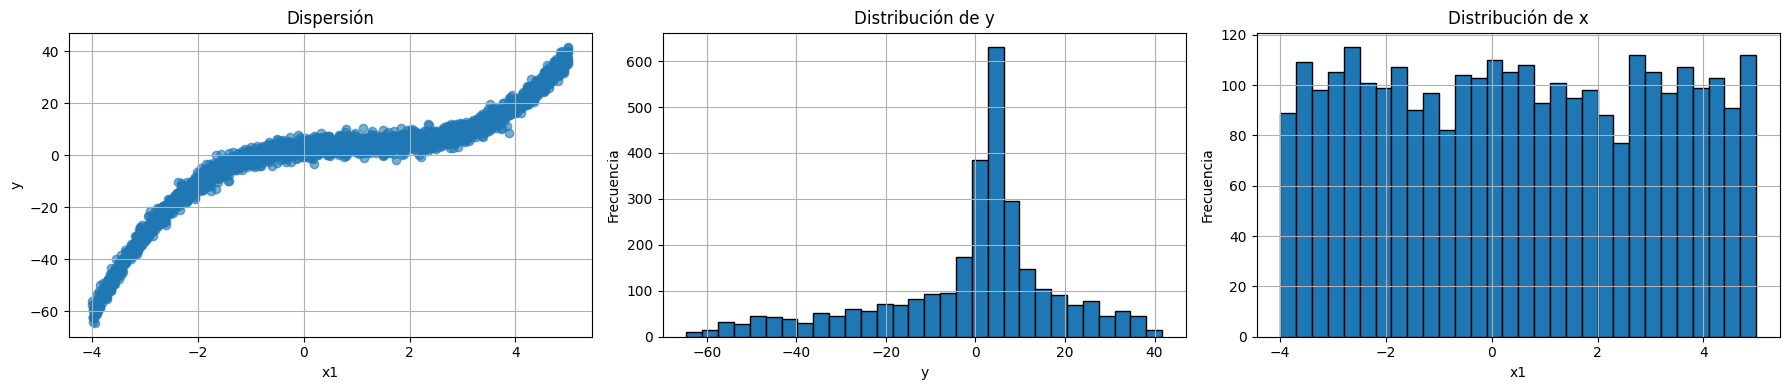

In [30]:
plot_regression_dataset(df_2, target_col="y")
plot_regression_diagnostics(df_2, target_col="y")

In [31]:
save_dataset(df_2, "regression_polynomial_1d.csv")

Dataset guardado en: ../data/mocked_data/regression_polynomial_1d.csv


### Regresión No Lineal Senoidal

In [32]:
df_3 = generate_regression_dataset(
    n_samples=3000,
    n_features=1,
    complexity="sinusoidal",
    noise_std=0.5,
    x_range=(-10, 10),
    random_state=42
)
df_3.head()

,x1,y
0,5.4791,0.011334
1,-1.2224,-3.564094
2,7.1720,3.110809
3,3.9474,-1.863431
4,-8.1165,-4.621355


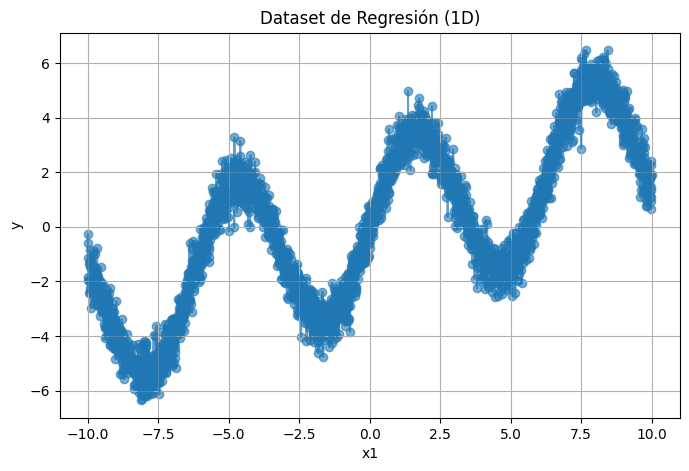

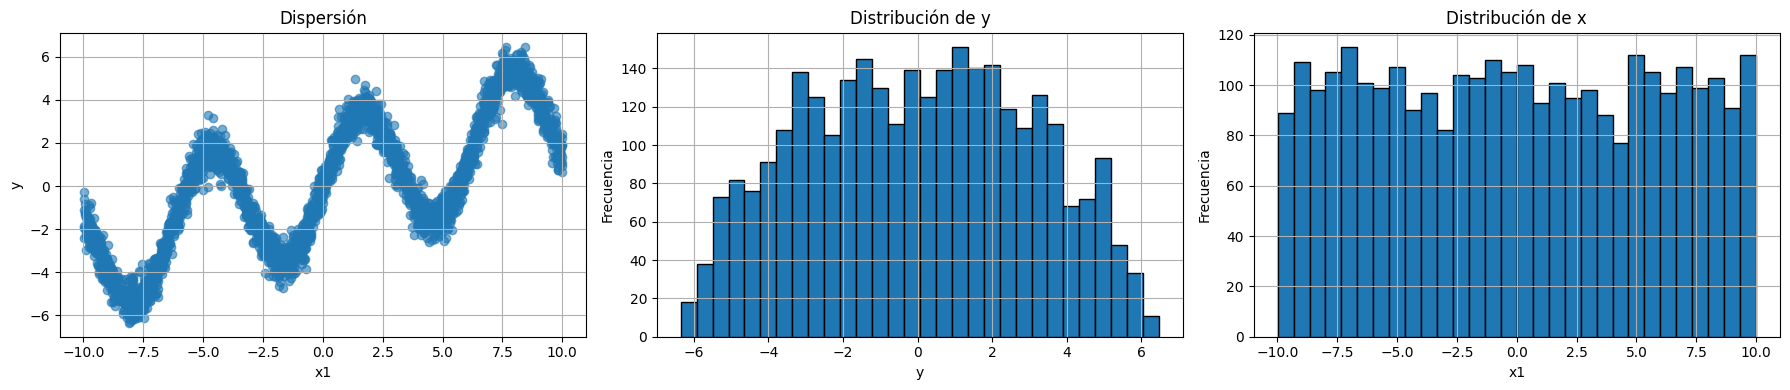

In [33]:
plot_regression_dataset(df_3, target_col="y")
plot_regression_diagnostics(df_3, target_col="y")

In [34]:
save_dataset(df_3, "regression_sinusoidal_1d.csv")

Dataset guardado en: ../data/mocked_data/regression_sinusoidal_1d.csv


### Regresión por Tramos

In [35]:
df_4 = generate_regression_dataset(
    n_samples=3000,
    n_features=1,
    complexity="piecewise",
    noise_std=0.7,
    x_range=(-6, 6),
    random_state=42
)
df_4.head()

,x1,y
0,3.2875,-3.835530
1,-0.7335,0.371096
2,4.3032,-8.524073
3,2.3684,-3.973673
4,-4.8699,-4.309711


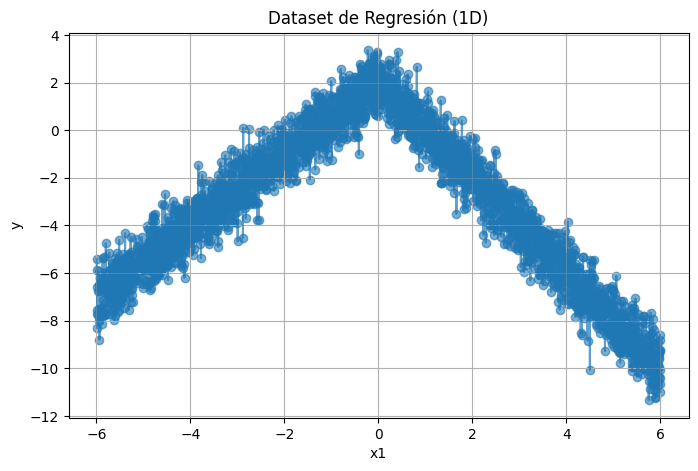

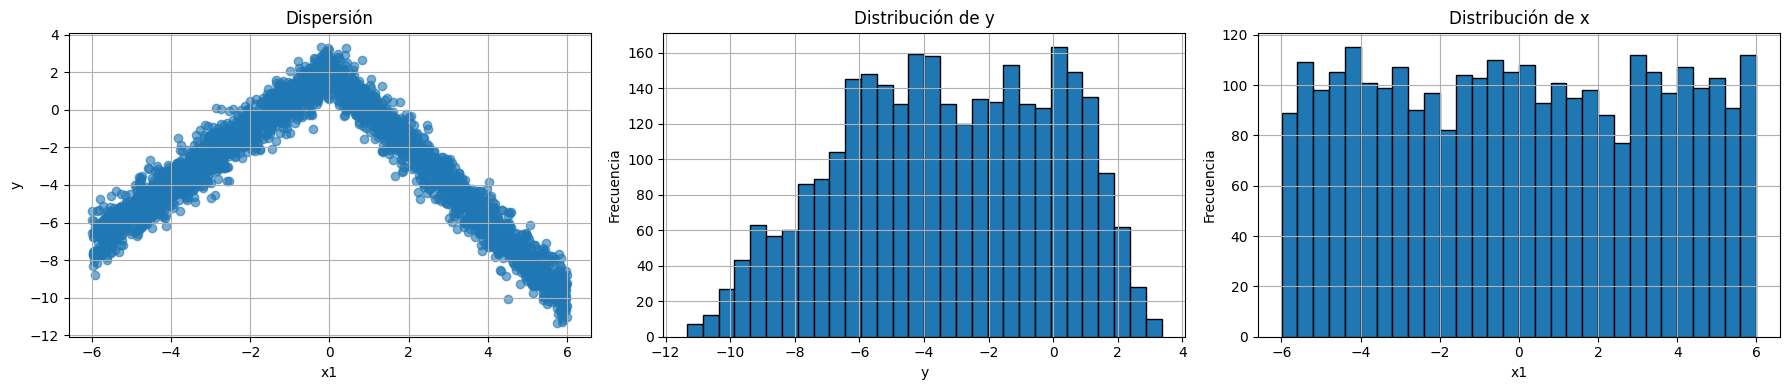

In [36]:
plot_regression_dataset(df_4, target_col="y")
plot_regression_diagnostics(df_4, target_col="y")

In [37]:
save_dataset(df_4, "regression_piecewise_1d.csv")

Dataset guardado en: ../data/mocked_data/regression_piecewise_1d.csv


### Regresión con Interacción entre Variables

In [38]:
df_5 = generate_regression_dataset(
    n_samples=5000,
    n_features=2,
    complexity="interaction",
    noise_std=1.0,
    x_range=(-4, 4),
    random_state=42
)
df_5.head()

,x1,x2,y
0,2.1916,-0.4890,-1.252147
1,2.8688,1.5789,12.630480
2,-3.2466,3.8050,-18.199165
3,2.0891,2.2885,11.034711
4,-2.9751,-0.3969,-1.595138


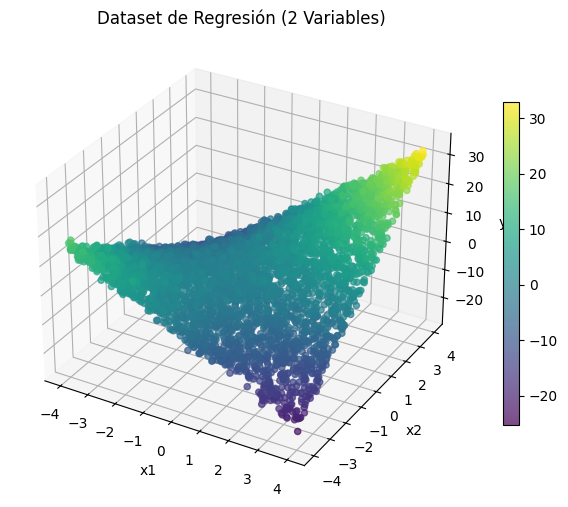

In [39]:
plot_regression_dataset(df_5, target_col="y")

In [40]:
save_dataset(df_5, "regression_interaction_2d.csv")

Dataset guardado en: ../data/mocked_data/regression_interaction_2d.csv
